In [32]:
from models import SABR, mSABR
from stats import PathStatistics
import numpy as np
F0 = 100
A0 = 0.4
rho = -0.3
T = 1.0
n_steps = 252
n_paths = 20000
beta = 0.5
nu = 1.5
lambda_ = [0,0.1,1,10]
theta = 0.2
seed = 42
stats_A = []
stats_F = []
F_path = []

for l in lambda_:
    msabr = mSABR(F0, A0, rho, T, n_steps, n_paths, beta, nu, l, theta, seed)
    F,A = msabr.run()
    stats_F.append(msabr.compute_stats(F))
    stats_A.append(msabr.compute_stats(A))
    F_path.append(F)
    print(np.isnan(F).any(), (F <= 0).any())
    print("min F:", np.nanmin(F))


True True
min F: -4.253307037470728
True True
min F: -2.8951434190189858
False False
min F: 6.691440706763681
False False
min F: 85.75976136467452


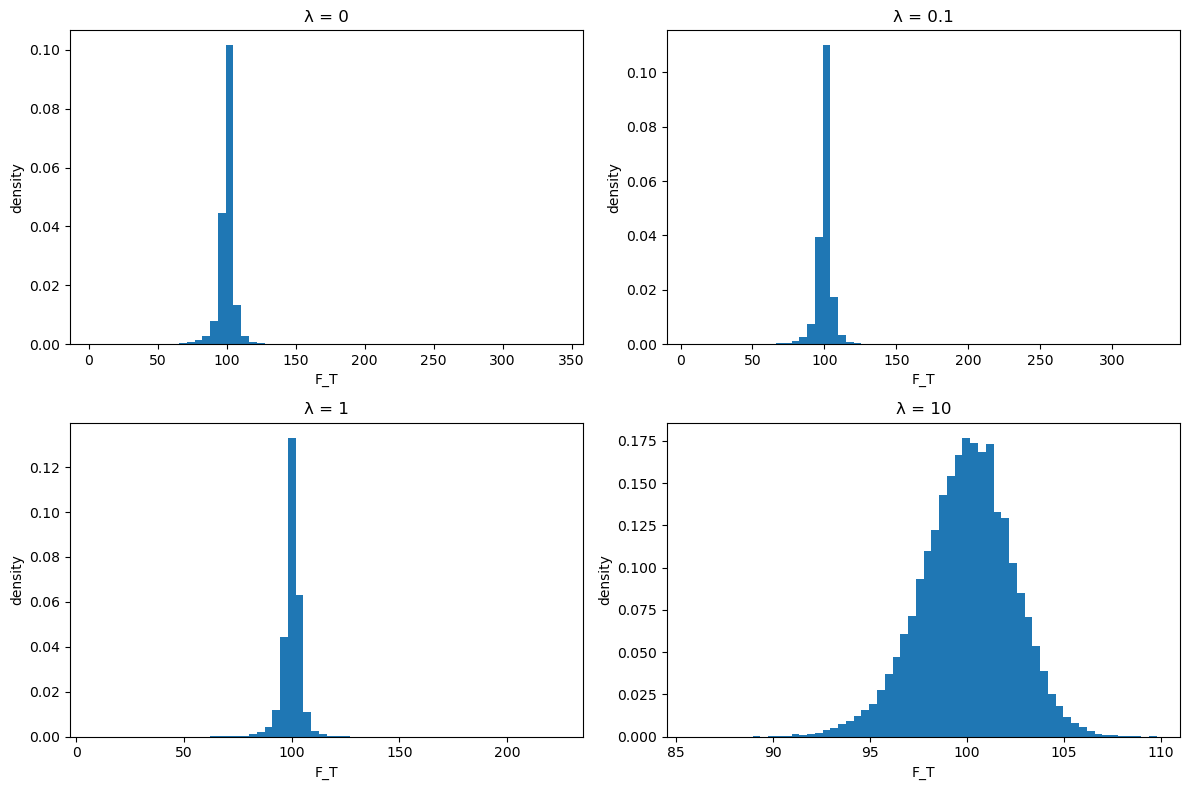

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, l, F in zip(axes.flat, lambda_, F_path):
    ax.hist(F[:, -1], bins=60, density=True)
    ax.set_title(f"λ = {l}")
    ax.set_xlabel("F_T")
    ax.set_ylabel("density")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
rows = []
for l, s in zip(lambda_, stats_F):
    rows.append({
        "lambda": l,
        "mean_T": s["mean"][-1],
        "var_T": s["variance"][-1],
        "skew_T": s["skewness"][-1],
        "kurt_T": s["kurtosis"][-1],
    })
pd.DataFrame(rows)

,lambda,mean_T,var_T,skew_T,kurt_T
0,0.0,NaN,NaN,NaN,NaN
1,0.1,NaN,NaN,NaN,NaN
2,1.0,99.96255,25.518336,-0.605119,54.368114
3,10.0,99.99159,5.678743,-0.256545,0.530888


In [29]:
stats_F

[{'mean': array([100.        , 100.00127272,  99.99812643,  99.99508334,
          99.99568455, 100.00060478, 100.00121726, 100.0005208 ,
         100.00006609, 100.00165888, 100.00120582,  99.99946028,
         100.00161991, 100.00184642, 100.00210965,  99.99714126,
          99.99770044,  99.99849676,  99.99925345, 100.00102048,
         100.00183698, 100.00246361, 100.00249376, 100.00315818,
         100.0035349 , 100.0037933 , 100.00490479, 100.00482005,
         100.00652954, 100.00762862, 100.00719721, 100.00793667,
         100.01402967, 100.01648788, 100.01881804, 100.01973571,
         100.01628576, 100.01564735, 100.01722078, 100.0207092 ,
         100.02252212, 100.02520777, 100.02351824, 100.02284122,
         100.02457211, 100.02016771, 100.0172191 , 100.01405003,
         100.01430815, 100.01430263, 100.01659388, 100.01537961,
         100.01820791, 100.01667722, 100.01491285, 100.01995574,
         100.02249865, 100.0206909 , 100.02289448, 100.01836617,
         100.0156

False False
min F: 85.75976136467452


When vol_of_vol coefficient is high, the path can go negative and that needs to be an absorbing state in the simulation
